# EEG Seizure Detection — Training Notebook

**Picks up from:** `test.ipynb` (preprocessing pipeline)  
**Input:** `.npy` epoch files saved by the preprocessing notebook  
**Output:** Trained model checkpoint + evaluation report

**Pipeline stages:**
1. Imports & configuration
2. Extended `EEGDatasetLoader` (with sampler + augmentation)
3. Train / Validation / Test split (patient-level)
4. Model definition (1D CNN)
5. Focal Loss
6. Training loop
7. Evaluation (AUC-ROC, Sensitivity, Specificity, F1)
8. Save checkpoint

---
## Section 1 — Imports & Configuration

In [9]:
import os
import gc
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    f1_score
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Directories (must match test.ipynb) ───────────────────────────────────────
CHBMIT_OUT_DIR = '../data/preprocessed/CHB-MIT'
SEINA_OUT_DIR  = '../data/preprocessed/Seina'

CHECKPOINT_DIR = '../checkpoints'
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

# ── Signal parameters (must match test.ipynb) ─────────────────────────────────
TARGET_SFREQ  = 256
WINDOW_SEC    = 4
N_CHANNELS    = 18
N_TIMEPOINTS  = TARGET_SFREQ * WINDOW_SEC   # 1024

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3
N_EPOCHS      = 1
PATIENCE      = 10          # early stopping patience
SEED          = 42

# ── Focal loss hyperparameters ────────────────────────────────────────────────
FOCAL_ALPHA   = 0.25        # down-weights easy negatives
FOCAL_GAMMA   = 2.0         # focusing parameter

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Configuration complete')
print(f'  Device        : {DEVICE}')
print(f'  Input shape   : ({N_CHANNELS}, {N_TIMEPOINTS})')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Learning rate : {LEARNING_RATE}')
print(f'  Focal α={FOCAL_ALPHA}, γ={FOCAL_GAMMA}')

✓ Configuration complete
  Device        : cuda
  Input shape   : (18, 1024)
  Batch size    : 32
  Learning rate : 0.001
  Focal α=0.25, γ=2.0


---
## Section 2 — Extended EEGDatasetLoader

Extends the loader from `test.ipynb` with:
- **`get_sampler()`** — `WeightedRandomSampler` so every batch sees ictal epochs
- **`_augment()`** — light augmentation on real ictal epochs only (no SMOTE)
- **`get_class_weights()`** — inverse-frequency weights for loss function

In [10]:
class EEGDatasetLoader:
    """
    Memory-mapped loader for preprocessed .npy EEG epoch files.
    Supports weighted sampling and ictal-only augmentation.

    Parameters
    ----------
    root_dirs   : list of preprocessed root directories
    augment     : if True, apply light augmentation to ictal epochs
    patients    : optional list of patient IDs to include (for splitting)
    n_channels  : expected number of channels — files with different shape are skipped
    n_timepoints: expected number of timepoints — files with different shape are skipped
    """

    def __init__(self, root_dirs, augment=False, patients=None,
                 n_channels=N_CHANNELS, n_timepoints=N_TIMEPOINTS):
        self.augment = augment

        epoch_files = []
        for root in root_dirs:
            for f in sorted(Path(root).rglob('*_epochs.npy')):
                patient_id = f.parent.name
                if patients is None or patient_id in patients:
                    epoch_files.append(f)

        # Memory-map all files, skip shape mismatches immediately
        self._epochs = []
        self._labels = []
        skipped = 0

        for f in epoch_files:
            ep = np.load(f, mmap_mode='r')
            # Shape: (n_epochs, n_channels, n_timepoints)
            if ep.ndim != 3 or ep.shape[1] != n_channels or ep.shape[2] != n_timepoints:
                print(f'  ⚠ Skipped {f.name}: shape {ep.shape} '
                      f'(expected (*, {n_channels}, {n_timepoints}))')
                skipped += 1
                continue
            lb = np.load(str(f).replace('_epochs', '_labels'), mmap_mode='r')
            self._epochs.append(ep)
            self._labels.append(lb)

        if skipped:
            print(f'  → {skipped} file(s) skipped due to shape mismatch')

        # Flat index: (file_idx, epoch_idx)
        self._index = [
            (fi, ei)
            for fi, ep in enumerate(self._epochs)
            for ei in range(len(ep))
        ]

        total   = len(self._index)
        n_ictal = sum(int(self._labels[fi][ei, 0]) for fi, ei in self._index)
        print(f'Dataset ready  : {total:,} epochs  |  '
              f'{n_ictal} ictal ({100*n_ictal/max(total,1):.3f}%)  |  '
              f'augment={augment}')

    # ── Core interface ────────────────────────────────────────────────────────

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        fi, ei  = self._index[idx]
        epoch   = np.array(self._epochs[fi][ei]).copy()
        binary  = int(self._labels[fi][ei, 0])
        stype   = int(self._labels[fi][ei, 1])

        if self.augment and binary == 1:
            epoch = self._augment(epoch)

        return (
            torch.tensor(epoch,  dtype=torch.float32),
            torch.tensor(binary, dtype=torch.long),
            torch.tensor(stype,  dtype=torch.long),
        )

    # ── Class imbalance helpers ───────────────────────────────────────────────

    def get_class_weights(self):
        all_labels      = np.concatenate([lb[:, 0] for lb in self._labels])
        classes, counts = np.unique(all_labels, return_counts=True)
        weights         = 1.0 / counts.astype(float)
        weights        /= weights.sum()
        return dict(zip(classes.tolist(), weights.tolist()))

    def get_sampler(self):
        all_labels     = np.array([int(self._labels[fi][ei, 0])
                                   for fi, ei in self._index])
        class_counts   = np.bincount(all_labels)
        sample_weights = np.where(
            all_labels == 1,
            1.0 / class_counts[1],
            1.0 / class_counts[0]
        )
        return WeightedRandomSampler(
            weights     = torch.tensor(sample_weights, dtype=torch.float32),
            num_samples = len(sample_weights),
            replacement = True
        )

    # ── Augmentation (ictal only) ─────────────────────────────────────────────

    def _augment(self, epoch):
        noise = np.random.normal(0, 0.01, epoch.shape).astype(np.float32)
        epoch = epoch + noise
        scale = np.random.uniform(0.90, 1.10)
        epoch = epoch * scale
        shift = np.random.randint(-100, 100)
        epoch = np.roll(epoch, shift, axis=1)
        return epoch.astype(np.float32)


print('✓ EEGDatasetLoader defined')

✓ EEGDatasetLoader defined


---
## Section 3 — Patient-Level Train / Val / Test Split

**Critical:** Split at the **patient level**, not the epoch level.  
If you split at the epoch level, the same patient appears in both train and test — the model memorizes patient-specific patterns and you get falsely inflated results.

Split: **70% train / 15% val / 15% test** (by number of patients)

In [11]:
def get_patient_ids(root_dirs):
    """Returns sorted list of all patient folder names across datasets."""
    ids = set()
    for root in root_dirs:
        for p in Path(root).iterdir():
            if p.is_dir():
                ids.add(p.name)
    return sorted(ids)


def patient_split(root_dirs, train_frac=0.70, val_frac=0.15, seed=SEED):
    """
    Splits patients into train/val/test sets.
    Returns three lists of patient IDs.
    """
    all_patients = get_patient_ids(root_dirs)
    rng = np.random.default_rng(seed)
    rng.shuffle(all_patients)

    n       = len(all_patients)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)

    train_patients = all_patients[:n_train]
    val_patients   = all_patients[n_train : n_train + n_val]
    test_patients  = all_patients[n_train + n_val :]

    print(f'Total patients : {n}')
    print(f'  Train        : {len(train_patients)} → {train_patients}')
    print(f'  Val          : {len(val_patients)}   → {val_patients}')
    print(f'  Test         : {len(test_patients)}  → {test_patients}')

    return train_patients, val_patients, test_patients


ROOT_DIRS = [CHBMIT_OUT_DIR, SEINA_OUT_DIR]

train_patients, val_patients, test_patients = patient_split(ROOT_DIRS)

# Build datasets
print('\nBuilding datasets...')
train_ds = EEGDatasetLoader(ROOT_DIRS, augment=True,  patients=train_patients)
val_ds   = EEGDatasetLoader(ROOT_DIRS, augment=False, patients=val_patients)
test_ds  = EEGDatasetLoader(ROOT_DIRS, augment=False, patients=test_patients)

# Build loaders
# Train: use WeightedRandomSampler to handle imbalance
# Val/Test: no sampling — we want to evaluate on true distribution
train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    sampler     = train_ds.get_sampler(),   # replaces shuffle=True
    num_workers = 0,
    pin_memory  = False
)
val_loader = DataLoader(
    val_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False
)
test_loader = DataLoader(
    test_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Total patients : 38
  Train        : 26 → ['chb14', 'chb09', 'chb16', 'PN07', 'PN06', 'chb11', 'chb24', 'PN10', 'chb15', 'chb21', 'chb05', 'PN13', 'chb10', 'chb13', 'chb22', 'chb03', 'PN09', 'chb12', 'chb17', 'chb07', 'PN12', 'chb18', 'chb06', 'PN05', 'PN00', 'chb02']
  Val          : 5   → ['chb04', 'chb19', 'PN16', 'chb08', 'PN14']
  Test         : 7  → ['chb01', 'chb23', 'PN03', 'chb20', 'PN01', 'PN17', 'PN11']

Building datasets...
  ⚠ Skipped PN00-1_epochs.npy: shape (1283, 12, 1024) (expected (*, 18, 1024))
  ⚠ Skipped PN00-2_epochs.npy: shape (1138, 12, 1024) (expected (*, 18, 1024))
  ⚠ Skipped PN00-3_epochs.npy: shape (1175, 12, 1024) (expected (*, 18, 1024))
  ⚠ Skipped PN00-4_epochs.npy: shape (1022, 12, 1024) (expected (*, 18, 1024))
  ⚠ Skipped PN00-5_epochs.npy: shape (1064, 12, 1024) (expected (*, 18, 1024))
  ⚠ Skipped PN05-2_epochs.npy: shape (3784, 10, 1024) (expected (*, 18, 1024))
  ⚠ Skipped PN05-3_epochs.npy: shape (2445, 10, 1024) (expected (*, 18, 1024))
  ⚠ Ski

---
## Section 4 — Model Definition (1D CNN)

A compact 1D CNN that operates directly on the raw (filtered, normalized) EEG signal.  
Input shape: `(batch, 18 channels, 1024 timepoints)`

In [12]:
class EEGConv1D(nn.Module):
    """
    Compact 1D CNN for binary seizure detection.

    Architecture:
        Input  : (B, 18, 1024)
        Conv blocks: progressively reduce time axis, increase features
        Head   : Global avg pool → FC → sigmoid

    Parameters
    ----------
    n_channels   : number of EEG channels (18)
    n_timepoints : samples per epoch (1024)
    n_classes    : 1 for binary (sigmoid), >1 for multi-class (softmax)
    dropout      : dropout rate in FC layers
    """

    def __init__(self, n_channels=18, n_timepoints=1024,
                 n_classes=1, dropout=0.5):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            # Block 1 — broad temporal features
            self._conv_block(n_channels, 32, kernel_size=63, stride=2),  # → (32, 481)
            # Block 2
            self._conv_block(32, 64, kernel_size=31, stride=2),          # → (64, 226)
            # Block 3
            self._conv_block(64, 128, kernel_size=15, stride=2),         # → (128, 106)
            # Block 4
            self._conv_block(128, 256, kernel_size=7, stride=2),         # → (256, 50)
            # Block 5 — fine temporal features
            self._conv_block(256, 256, kernel_size=3, stride=1),         # → (256, 48)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)   # → (256, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    @staticmethod
    def _conv_block(in_ch, out_ch, kernel_size, stride):
        padding = kernel_size // 2
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size,
                      stride=stride, padding=padding, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

    def forward(self, x):
        # x: (B, C, T)
        x = self.conv_blocks(x)      # (B, 256, T')
        x = self.global_pool(x)      # (B, 256, 1)
        x = self.classifier(x)       # (B, n_classes)
        return x.squeeze(-1)         # (B,) for binary


# Instantiate and inspect
model = EEGConv1D(
    n_channels   = N_CHANNELS,
    n_timepoints = N_TIMEPOINTS,
    n_classes    = 1,
    dropout      = 0.5
).to(DEVICE)

# Parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ Model defined: EEGConv1D')
print(f'  Trainable parameters: {n_params:,}')

# Sanity check — forward pass with dummy batch
dummy = torch.randn(4, N_CHANNELS, N_TIMEPOINTS).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'  Output shape (batch=4): {out.shape}   ← expected: torch.Size([4])')

✓ Model defined: EEGConv1D
  Trainable parameters: 691,329
  Output shape (batch=4): torch.Size([4])   ← expected: torch.Size([4])


---
## Section 5 — Focal Loss

Focal Loss down-weights easy (normal) examples automatically and focuses training on hard/rare (ictal) examples.  
This is better than plain weighted BCE for extreme imbalance like 4528:1.

In [13]:
class FocalLoss(nn.Module):
    """
    Binary Focal Loss for extreme class imbalance.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Parameters
    ----------
    alpha : float — balances positive/negative class weight (0.25 standard)
    gamma : float — focusing parameter; 0 = standard BCE, 2 = standard focal
    """

    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        """
        logits  : (B,)  raw model output (before sigmoid)
        targets : (B,)  binary labels 0/1
        """
        targets = targets.float()
        bce     = F.binary_cross_entropy_with_logits(
                      logits, targets, reduction='none')

        pt      = torch.exp(-bce)                            # p_t
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal   = alpha_t * (1 - pt) ** self.gamma * bce

        return focal.mean()


criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                              weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5)  # monitors val AUC-ROC

print('✓ FocalLoss defined')
print(f'  alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}')
print('✓ Optimizer: Adam  lr={LEARNING_RATE}  weight_decay=1e-4')
print('✓ Scheduler: ReduceLROnPlateau  (monitors val AUC-ROC)')

✓ FocalLoss defined
  alpha=0.25, gamma=2.0
✓ Optimizer: Adam  lr={LEARNING_RATE}  weight_decay=1e-4
✓ Scheduler: ReduceLROnPlateau  (monitors val AUC-ROC)


---
## Section 6 — Training Loop

Includes:
- Early stopping on validation AUC-ROC
- Best model checkpointing
- Per-epoch loss + AUC logging

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for epochs_batch, labels, _ in loader:
        epochs_batch = epochs_batch.to(device)
        labels       = labels.to(device)

        optimizer.zero_grad()
        logits = model(epochs_batch)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — stabilizes training on EEG data
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loader(model, loader, criterion, device):
    """
    Returns dict with loss, auc, sensitivity, specificity, f1.
    """
    model.eval()
    total_loss  = 0.0
    all_probs   = []
    all_labels  = []

    for epochs_batch, labels, _ in loader:
        epochs_batch = epochs_batch.to(device)
        labels_dev   = labels.to(device)

        logits = model(epochs_batch)
        loss   = criterion(logits, labels_dev)
        total_loss += loss.item()

        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= 0.5).astype(int)

    # Guard against edge case where val set has no ictal epochs
    if len(np.unique(all_labels)) < 2:
        auc = 0.0
    else:
        auc = roc_auc_score(all_labels, all_probs)

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds,
                                       labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    f1          = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss'       : total_loss / len(loader),
        'auc'        : auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1'         : f1,
    }


print('✓ Train/eval functions defined')

✓ Train/eval functions defined


In [15]:
# ── Main Training Loop ────────────────────────────────────────────────────────

history = defaultdict(list)
best_val_auc    = 0.0
patience_counter = 0
best_ckpt_path  = Path(CHECKPOINT_DIR) / 'best_model.pt'

print(f'Starting training for up to {N_EPOCHS} epochs (patience={PATIENCE})\n')
print(f'{"Epoch":>5}  {"Train Loss":>10}  {"Val Loss":>8}  '
      f'{"Val AUC":>8}  {"Sens":>6}  {"Spec":>6}  {"F1":>6}')
print('-' * 70)

for epoch in range(1, N_EPOCHS + 1):

    train_loss = train_one_epoch(model, train_loader, criterion,
                                  optimizer, DEVICE)
    val_metrics = evaluate_loader(model, val_loader, criterion, DEVICE)

    # Scheduler step — reduce LR if val AUC plateaus
    scheduler.step(val_metrics['auc'])

    # Log
    history['train_loss'].append(train_loss)
    for k, v in val_metrics.items():
        history[f'val_{k}'].append(v)

    star = ''
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        patience_counter = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_auc'    : best_val_auc,
            'config'     : {
                'n_channels'  : N_CHANNELS,
                'n_timepoints': N_TIMEPOINTS,
                'target_sfreq': TARGET_SFREQ,
                'window_sec'  : WINDOW_SEC,
            }
        }, best_ckpt_path)
        star = '  ← best'
    else:
        patience_counter += 1

    print(f'{epoch:>5}  {train_loss:>10.4f}  '
          f'{val_metrics["loss"]:>8.4f}  '
          f'{val_metrics["auc"]:>8.4f}  '
          f'{val_metrics["sensitivity"]:>6.3f}  '
          f'{val_metrics["specificity"]:>6.3f}  '
          f'{val_metrics["f1"]:>6.3f}'
          f'{star}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

print(f'\n✓ Training complete  |  Best val AUC: {best_val_auc:.4f}')
print(f'  Checkpoint saved to: {best_ckpt_path}')

Starting training for up to 1 epochs (patience=10)

Epoch  Train Loss  Val Loss   Val AUC    Sens    Spec      F1
----------------------------------------------------------------------
    1      0.0031    0.0006    0.8850   0.208   1.000   0.134  ← best

✓ Training complete  |  Best val AUC: 0.8850
  Checkpoint saved to: ..\checkpoints\best_model.pt


---
## Section 7 — Training Curves

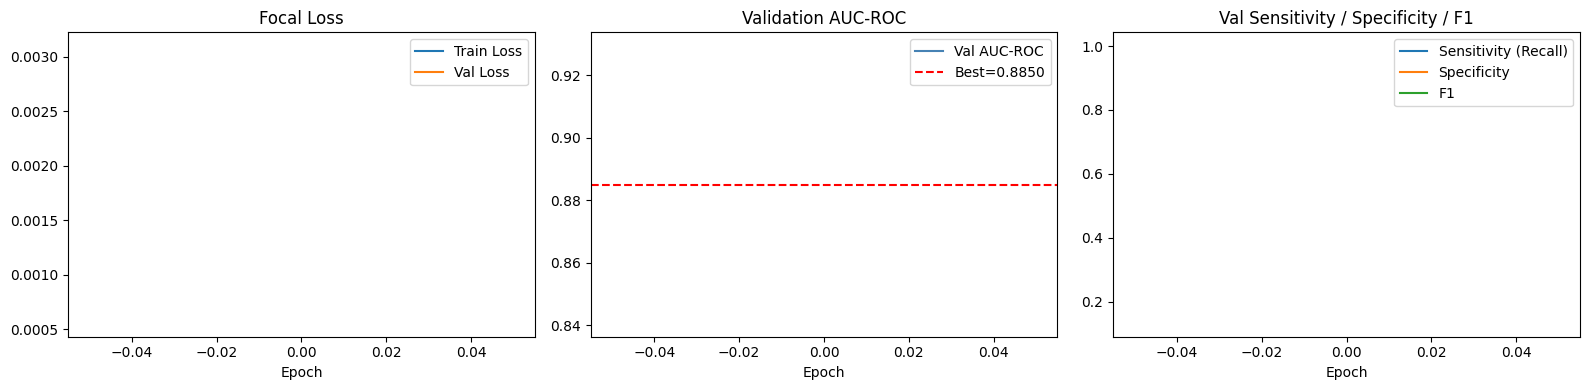

✓ Training curves saved


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Focal Loss'); axes[0].legend()
axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_auc'], label='Val AUC-ROC', color='steelblue')
axes[1].axhline(best_val_auc, color='red', linestyle='--',
                label=f'Best={best_val_auc:.4f}')
axes[1].set_title('Validation AUC-ROC'); axes[1].legend()
axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_sensitivity'], label='Sensitivity (Recall)')
axes[2].plot(history['val_specificity'], label='Specificity')
axes[2].plot(history['val_f1'],          label='F1')
axes[2].set_title('Val Sensitivity / Specificity / F1'); axes[2].legend()
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(Path(CHECKPOINT_DIR) / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Training curves saved')

---
## Section 8 — Final Evaluation on Test Set

Load the best checkpoint and evaluate on held-out patients.

In [17]:
# Load best checkpoint
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]}  '
      f'(val AUC={ckpt["val_auc"]:.4f})')

# Full evaluation on test set
model.eval()
all_probs  = []
all_labels = []

with torch.no_grad():
    for epochs_batch, labels, _ in test_loader:
        logits = model(epochs_batch.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs >= 0.5).astype(int)

print('\n' + '='*55)
print('TEST SET RESULTS')
print('='*55)
print(classification_report(
    all_labels, all_preds,
    target_names=['Normal (0)', 'Ictal (1)'],
    digits=4
))

auc = roc_auc_score(all_labels, all_probs)
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds, labels=[0,1]).ravel()
sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
far         = fp / (fp + tn + 1e-8)   # False Alarm Rate

print(f'ROC-AUC              : {auc:.4f}')
print(f'Sensitivity (recall) : {sensitivity:.4f}   ← most critical clinically')
print(f'Specificity          : {specificity:.4f}')
print(f'False Alarm Rate     : {far:.4f}   ← clinically important')
print(f'\nConfusion Matrix:')
print(f'  TN={tn:,}  FP={fp:,}')
print(f'  FN={fn:,}  TP={tp:,}')

Loaded checkpoint from epoch 1  (val AUC=0.8850)

TEST SET RESULTS
              precision    recall  f1-score   support

  Normal (0)     0.9992    0.9996    0.9994    150919
   Ictal (1)     0.0290    0.0165    0.0211       121

    accuracy                         0.9988    151040
   macro avg     0.5141    0.5080    0.5102    151040
weighted avg     0.9984    0.9988    0.9986    151040

ROC-AUC              : 0.8305
Sensitivity (recall) : 0.0165   ← most critical clinically
Specificity          : 0.9996
False Alarm Rate     : 0.0004   ← clinically important

Confusion Matrix:
  TN=150,852  FP=67
  FN=119  TP=2


---
## Section 9 — Threshold Tuning

The default threshold of 0.5 is not optimal for imbalanced data.  
Sweep the threshold to find the operating point that best balances sensitivity and false alarm rate for clinical use.

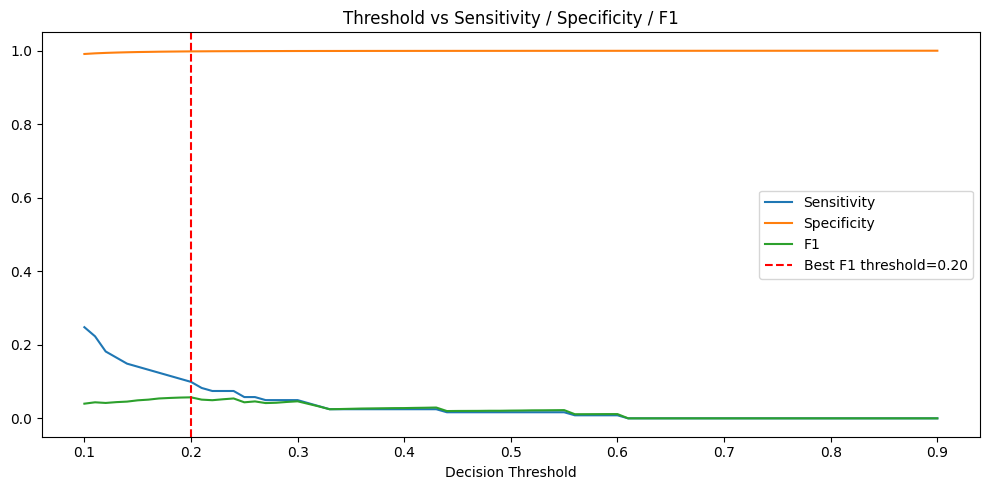

Best threshold (by F1) : 0.20
  Sensitivity           : 0.0992
  Specificity           : 0.9981
  F1                    : 0.0571


In [18]:
thresholds   = np.linspace(0.1, 0.9, 81)
sensitivities = []
specificities = []
f1_scores     = []

for thresh in thresholds:
    preds = (all_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds, labels=[0,1]).ravel()
    sensitivities.append(tp / (tp + fn + 1e-8))
    specificities.append(tn / (tn + fp + 1e-8))
    f1_scores.append(f1_score(all_labels, preds, zero_division=0))

# Best threshold by F1
best_idx   = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, sensitivities, label='Sensitivity')
ax.plot(thresholds, specificities, label='Specificity')
ax.plot(thresholds, f1_scores,     label='F1')
ax.axvline(best_thresh, color='red', linestyle='--',
           label=f'Best F1 threshold={best_thresh:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_title('Threshold vs Sensitivity / Specificity / F1')
ax.legend()
plt.tight_layout()
plt.savefig(Path(CHECKPOINT_DIR) / 'threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best threshold (by F1) : {best_thresh:.2f}')
print(f'  Sensitivity           : {sensitivities[best_idx]:.4f}')
print(f'  Specificity           : {specificities[best_idx]:.4f}')
print(f'  F1                    : {f1_scores[best_idx]:.4f}')